# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

**Declaration:** I have completed this version without generative AI.

**Student(s):** Jacob Khaykin

**Date:** 9/10/2026

My Q1 solution process is attached below. I will use this space to answer questions relating to Q2.

# Q1
![Q1 handwritten solution](images/q1_solution.jpg)

# Q2 
1. In the python cell below this one, I have successfully loaded in the ForeignGifts_edu.csv dataset and assigned it to df.

2. I created a histogram for the Foreign Gift Amount variable and noticed that when I used the raw data, the scaling was really bad because very large numbers compared to the mean scaled the histogram too far to where it was very right skewed and hard to see any major findings. To fix this problem, I decided to transform it by the arcsinh function. 

3. I used a bar chart of the value counts along with value_counts(normalize=True) to get the proportions. After running the code it turned out that contracts make up about 61.2% of the records, monetary gifts about 38.8%, and real estate only about 0.04%.

4. When I first built the KDE, I kept getting negative/non real solution issues because I was trying to do the KDE of a log based function, so I had to drop the 24 negative amounts first because the log is undefined there. The overall density is roughly bell shaped but slightly left skewed on the log scale, centered near a log value of 11.5, which is about $100,000. When I split by gift type, contracts sit slightly higher and tighter than monetary gifts, which spread out wider and flatter with more mass down in the small-gift range, while real estate sits furthest right of the three but rests on only 11 observations, so its curve is too noisy for me to read much into.

5. The top 15 countries by number of gifts are England (3,655), China (2,461), Canada (2,344), Japan (1,896), and Switzerland (1,676). However, by total amount given Qatar is actually first at about $2.71 billion, then England at $1.46 billion, China at $1.24 billion, and Saudi Arabia at $1.07 billion. The two lists are not the same. Beyond that, I also noticed that Bermuda, the United Arab Emirates, Singapore, and Australia appear in the money top 15 but not the count top 15, which means that they give few but very large gifts.

6. Now by grouping by Giftor Name and summing, the largest single giftor is Qatar Foundation at about $1.17 billion, followed by "Qatar Foundation/Qatar National Res" at about $796 million and "Qatar Foundation for Education" at about $374 million. These look like the same organization entered under three different names, so combined they are about $2.34 billion, which is most of Qatar's country total. After those, the largest giftors are "Anonymous" at about $339 million and the Saudi Arabian Cultural Mission at about $275 million. I realized that the "Anonymous" entry is not one real donor, so it shouldn't really be considered as the biggest single giftor.


   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country of Giftor                          Giftor Name  
0             CHINA                                  NaN  
1             CHINA     Confucius Institute Headquarters  

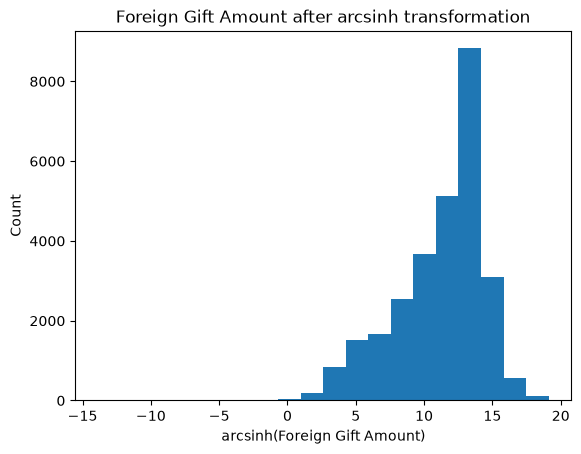

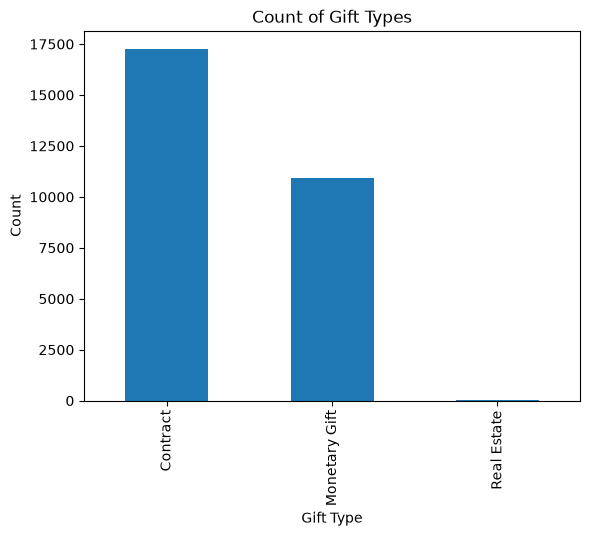

The proportion of each gift type is:
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


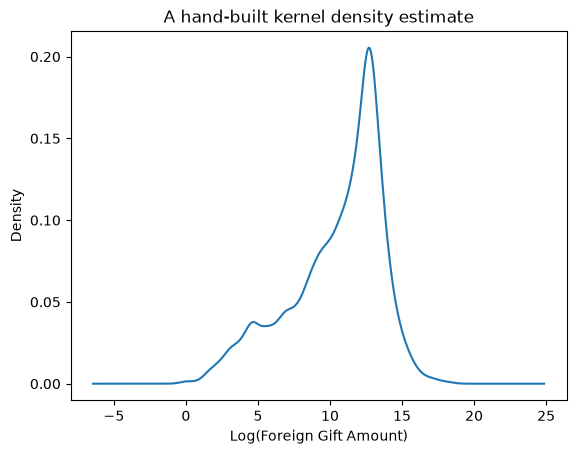

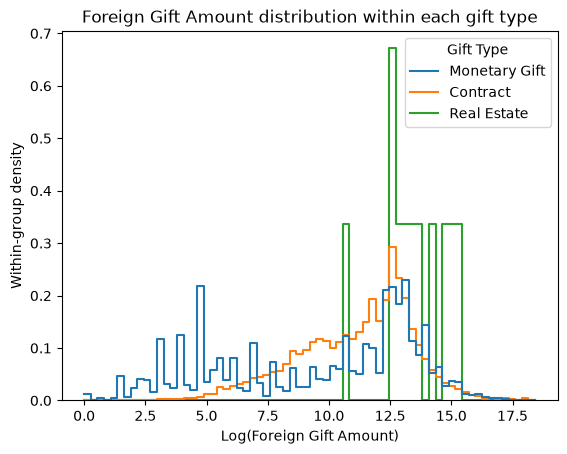

The top 15 countries of giftors are:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
The top 15 countries of giftors by total gift amount are:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401

In [27]:
# Your Phase 1 solution to the problem goes here.
#Q1 Image attached below
#Q2 Work here:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("data/ForeignGifts_edu.csv", low_memory=False)
print(df.head())
df["fga_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])

df["fga_arcsinh"].hist(bins=20, grid=False)
plt.title("Foreign Gift Amount after arcsinh transformation")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()

df["Gift Type"].value_counts().plot(kind="bar")
plt.title("Count of Gift Types")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

print("The proportion of each gift type is:")
print(df["Gift Type"].value_counts(normalize=True))

pos = df.loc[df["Foreign Gift Amount"] > 0]
log_amt = np.log(pos["Foreign Gift Amount"])

N = len(log_amt)
sample_sd = np.std(log_amt, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(log_amt.min() - 2 * sample_sd, log_amt.max() + 2 * sample_sd, 500)

def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

kde = sum(normal_kernel(value, h_s) for value in log_amt) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="A hand-built kernel density estimate", xlabel="Log(Foreign Gift Amount)", ylabel="Density")
plt.show()

ax = sns.histplot(
    data=pos,
    x=log_amt,
    hue="Gift Type",
    stat="density",
    common_norm=False,
    multiple="layer",
    element="step",
    fill=False,
)
ax.set(title="Foreign Gift Amount distribution within each gift type", xlabel="Log(Foreign Gift Amount)", ylabel="Within-group density")
plt.show()

print("The top 15 countries of giftors are:")
print(df["Country of Giftor"].value_counts().head(15))

print("The top 15 countries of giftors by total gift amount are:")
print(df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

print("The top 15 giftors by total gift amount are:")
print(df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [28]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]